In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from keras.models import Sequential
from keras.layers import Dense, Activation, Layer, Lambda
from sklearn.decomposition import PCA
from mlxtend.plotting import plot_decision_regions
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_regression
import tensorflow as tf

In [2]:
import warnings
warnings.simplefilter('ignore')

In [3]:
df=pd.read_csv(r"C:\Users\sanum\Desktop\assignment\assignments data\Neural networks\gas_turbines.csv")

In [4]:
df1=df[['AT', 'AP', 'AH', 'TEY']]
df1.head()

,AT,AP,AH,TEY
0,6.8594,1007.9,96.799,114.70
1,6.7850,1008.4,97.118,114.72
2,6.8977,1008.8,95.939,114.71
3,7.0569,1009.2,95.249,114.72
4,7.3978,1009.7,95.150,114.72


In [5]:
df1.isnull(). sum()

AT     0
AP     0
AH     0
TEY    0
dtype: int64

In [6]:
df1.describe().T

,count,mean,std,min,25%,50%,75%,max
AT,15039.0,17.764381,7.574323,0.5223,11.408,18.186,23.8625,34.929
AP,15039.0,1013.199240,6.410760,985.8500,1008.900,1012.800,1016.9000,1034.200
AH,15039.0,79.124174,13.793439,30.3440,69.750,82.266,90.0435,100.200
TEY,15039.0,134.188464,15.829717,100.1700,127.985,133.780,140.8950,174.610


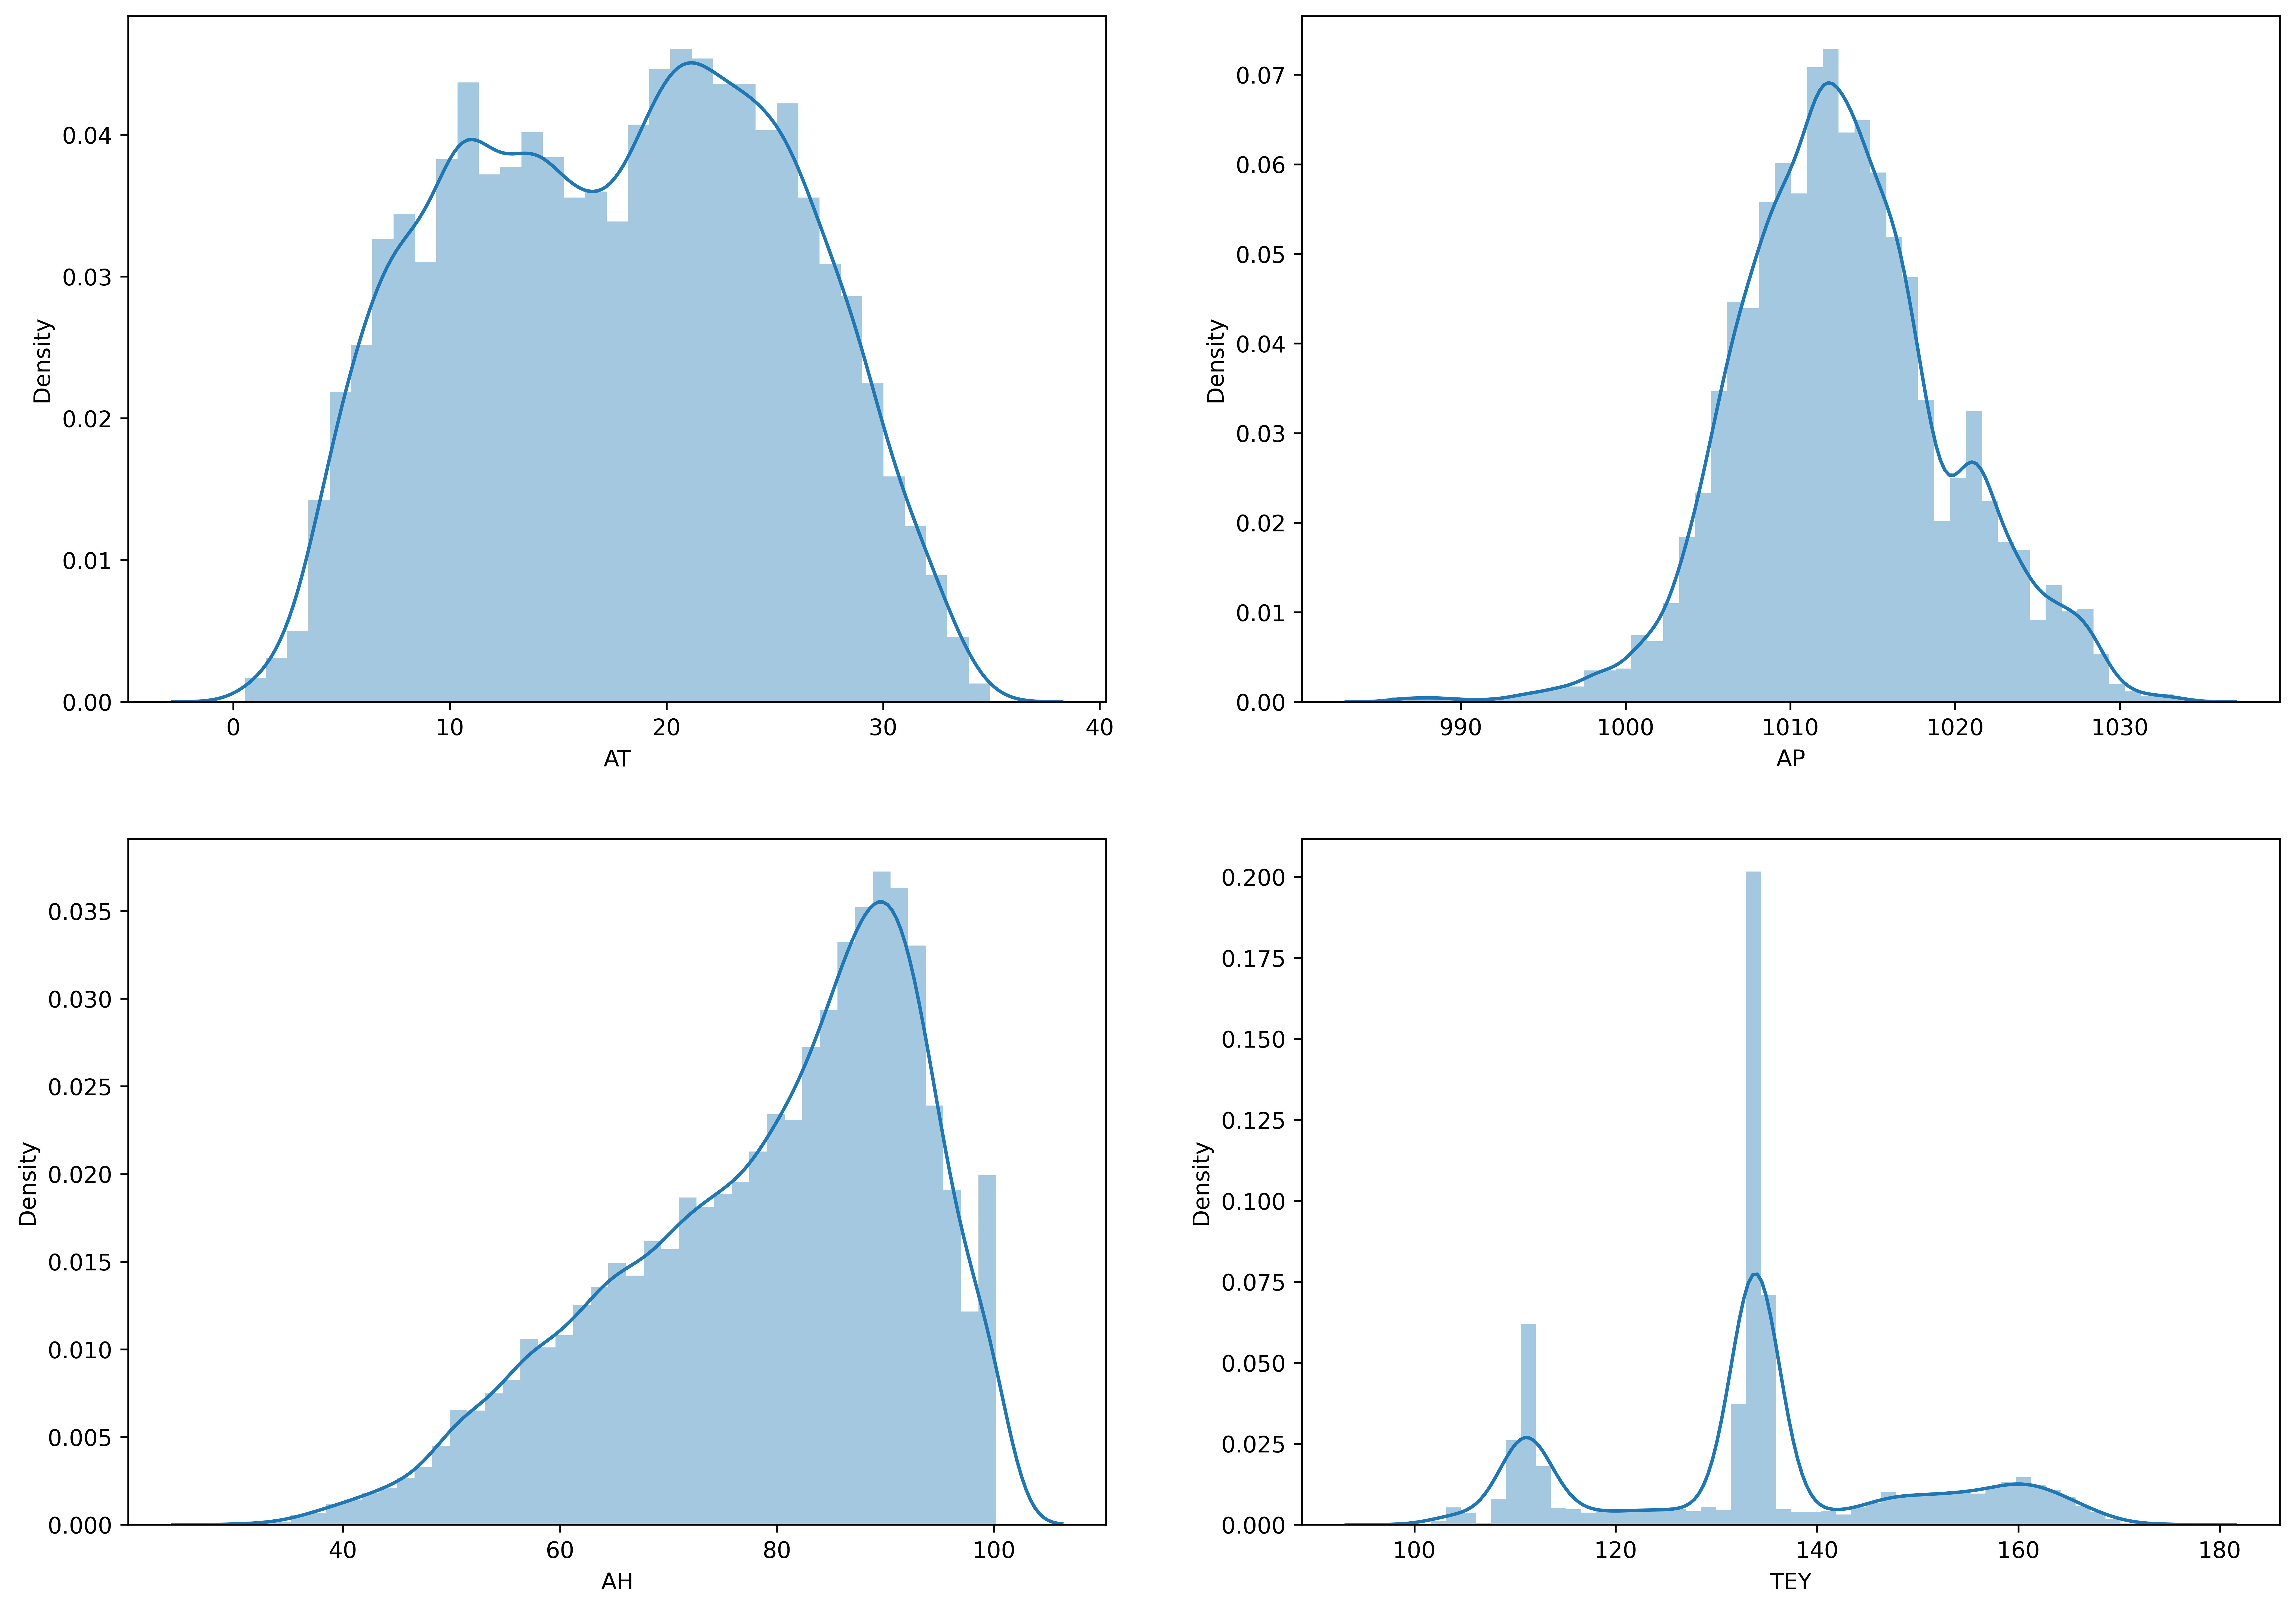

In [7]:
fig, ax = plt.subplots(2,2, figsize = (17,12),dpi=600)

sns.distplot(df.AT, ax = ax[0,0])
sns.distplot(df.AP, ax = ax[0,1])
sns.distplot(df.AH, ax = ax[1,0])
sns.distplot(df.TEY, ax = ax[1,1])
plt.show()

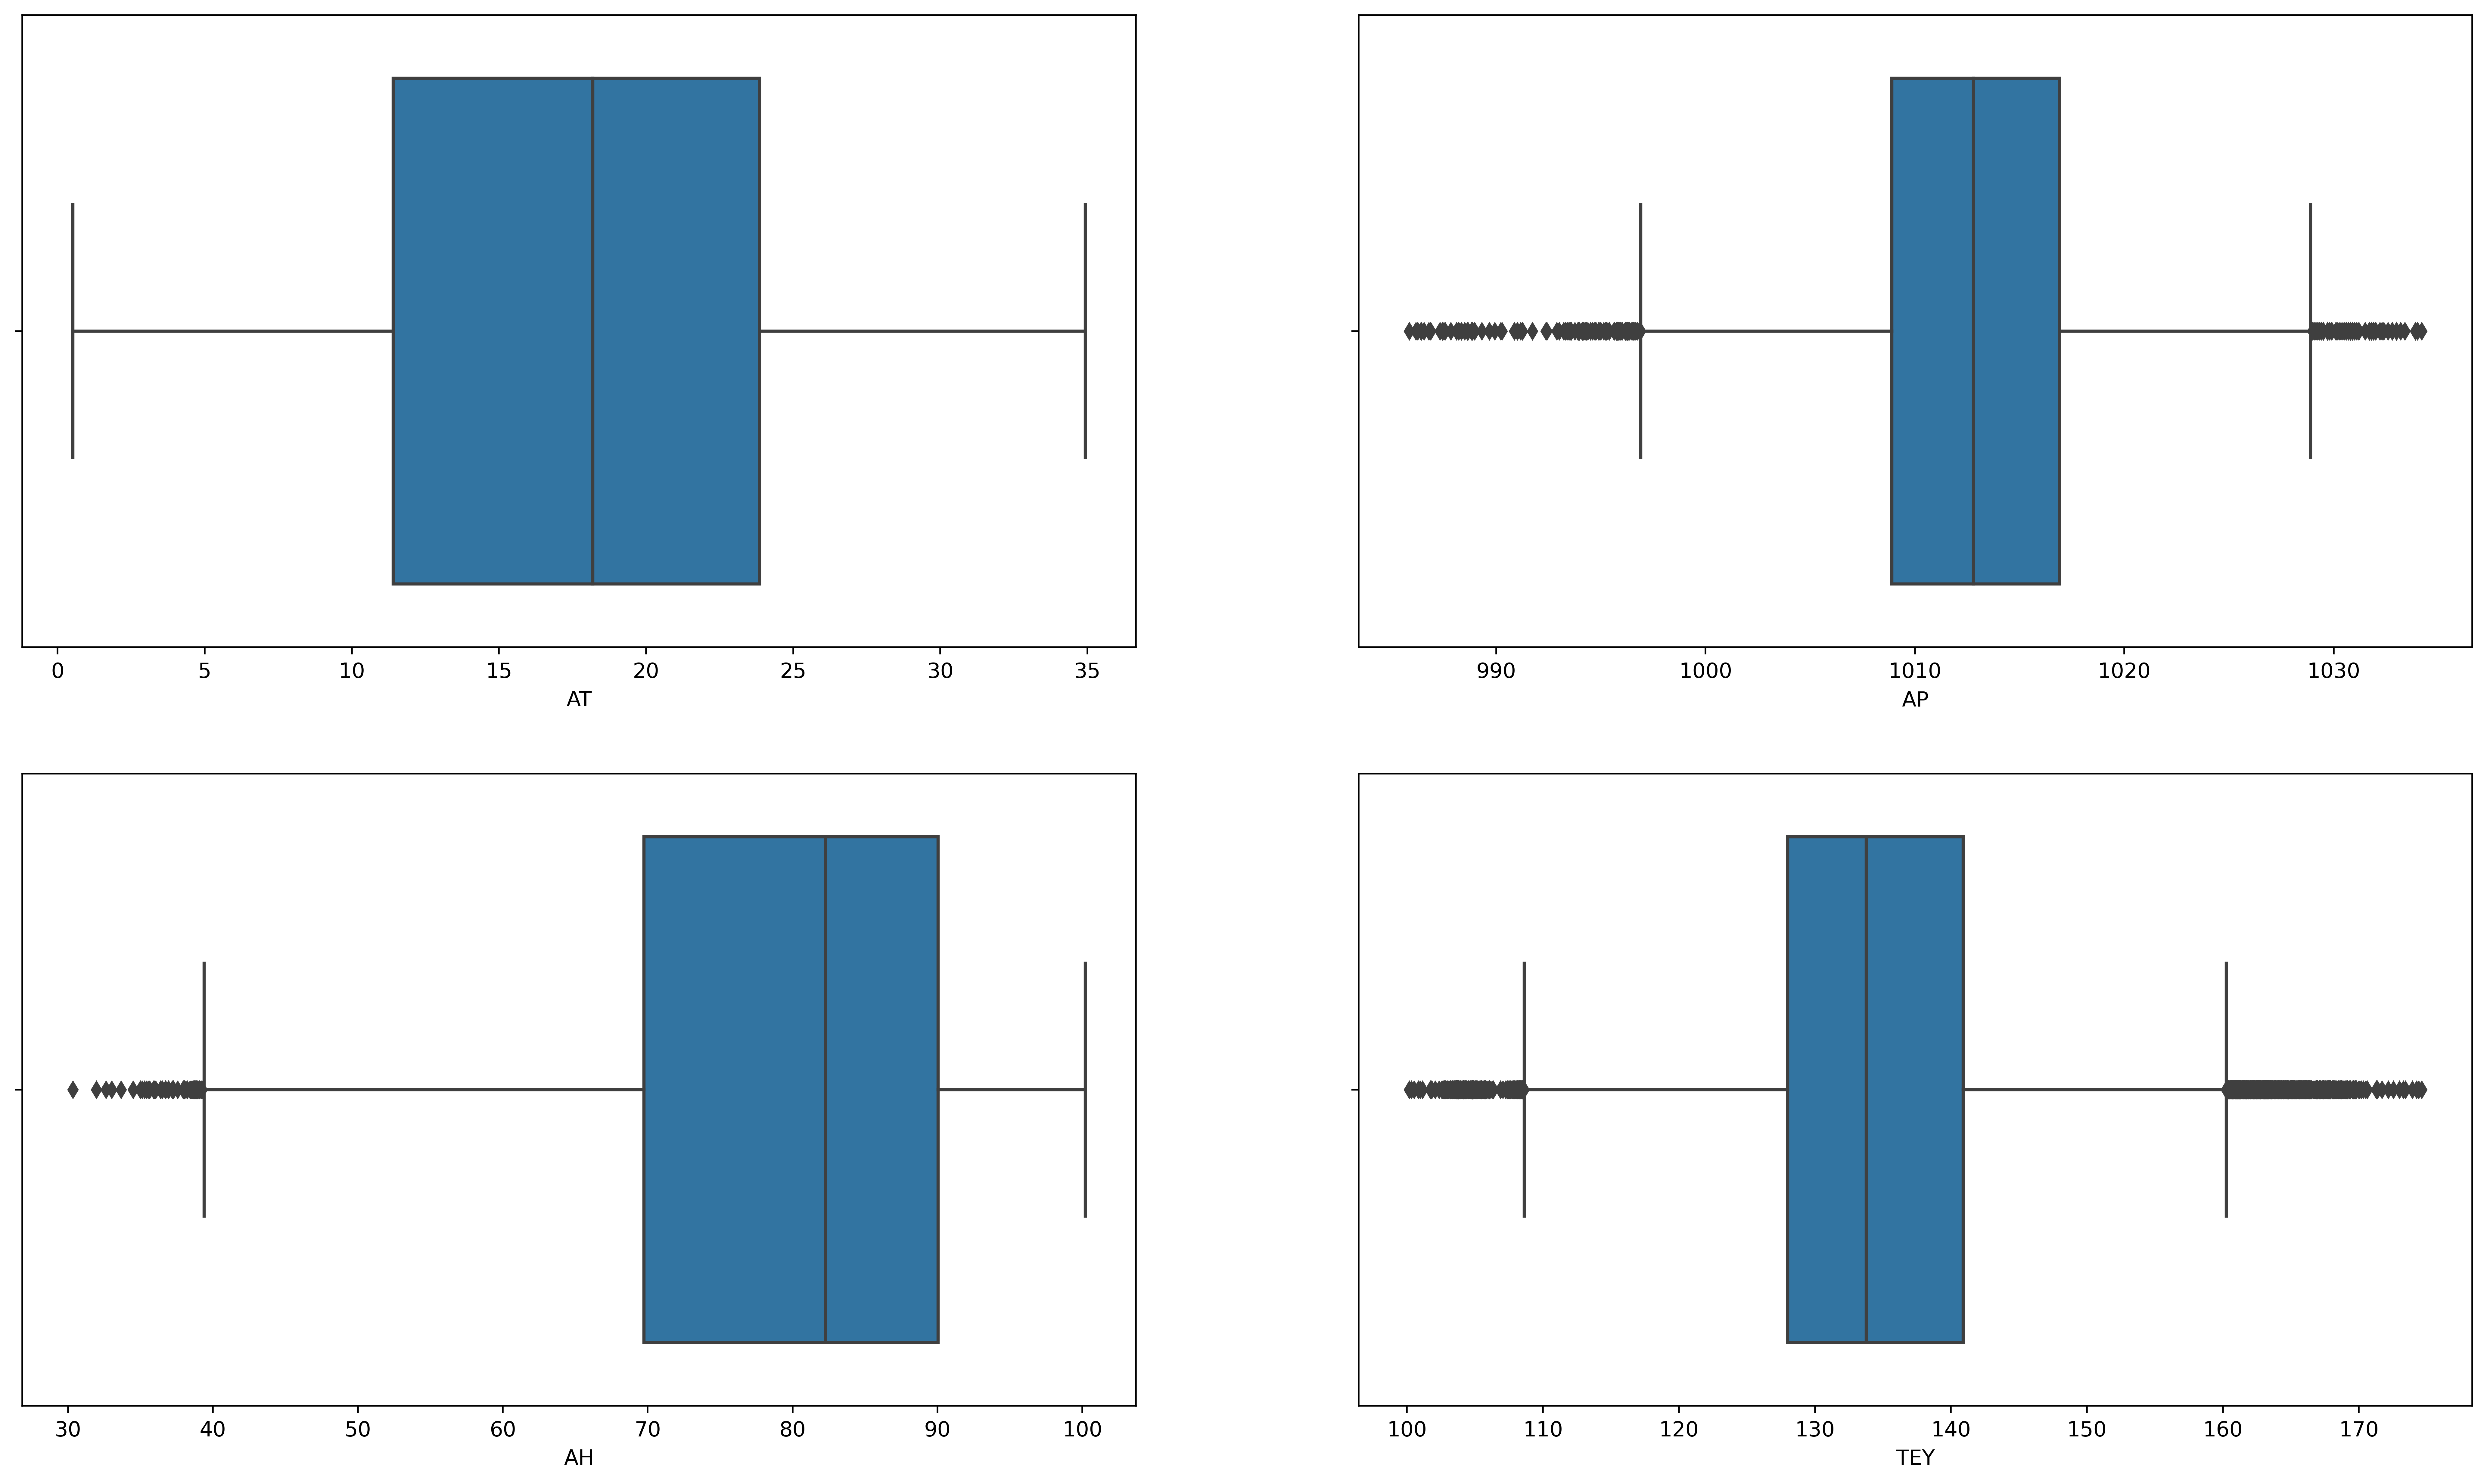

In [8]:
fig, axes=plt.subplots(nrows=2, ncols=2, figsize=(21,12),dpi=500)
sns.boxplot(x='AT', data=df, ax=axes[0,0])
sns.boxplot(x='AH', data=df, ax=axes[1,0])
sns.boxplot(x='AP', data=df, ax=axes[0,1])
sns.boxplot(x='TEY', data=df, ax=axes[1,1])
plt.show()

Text(0.5, 1.0, 'Histogram of the Target Column (TEY)')

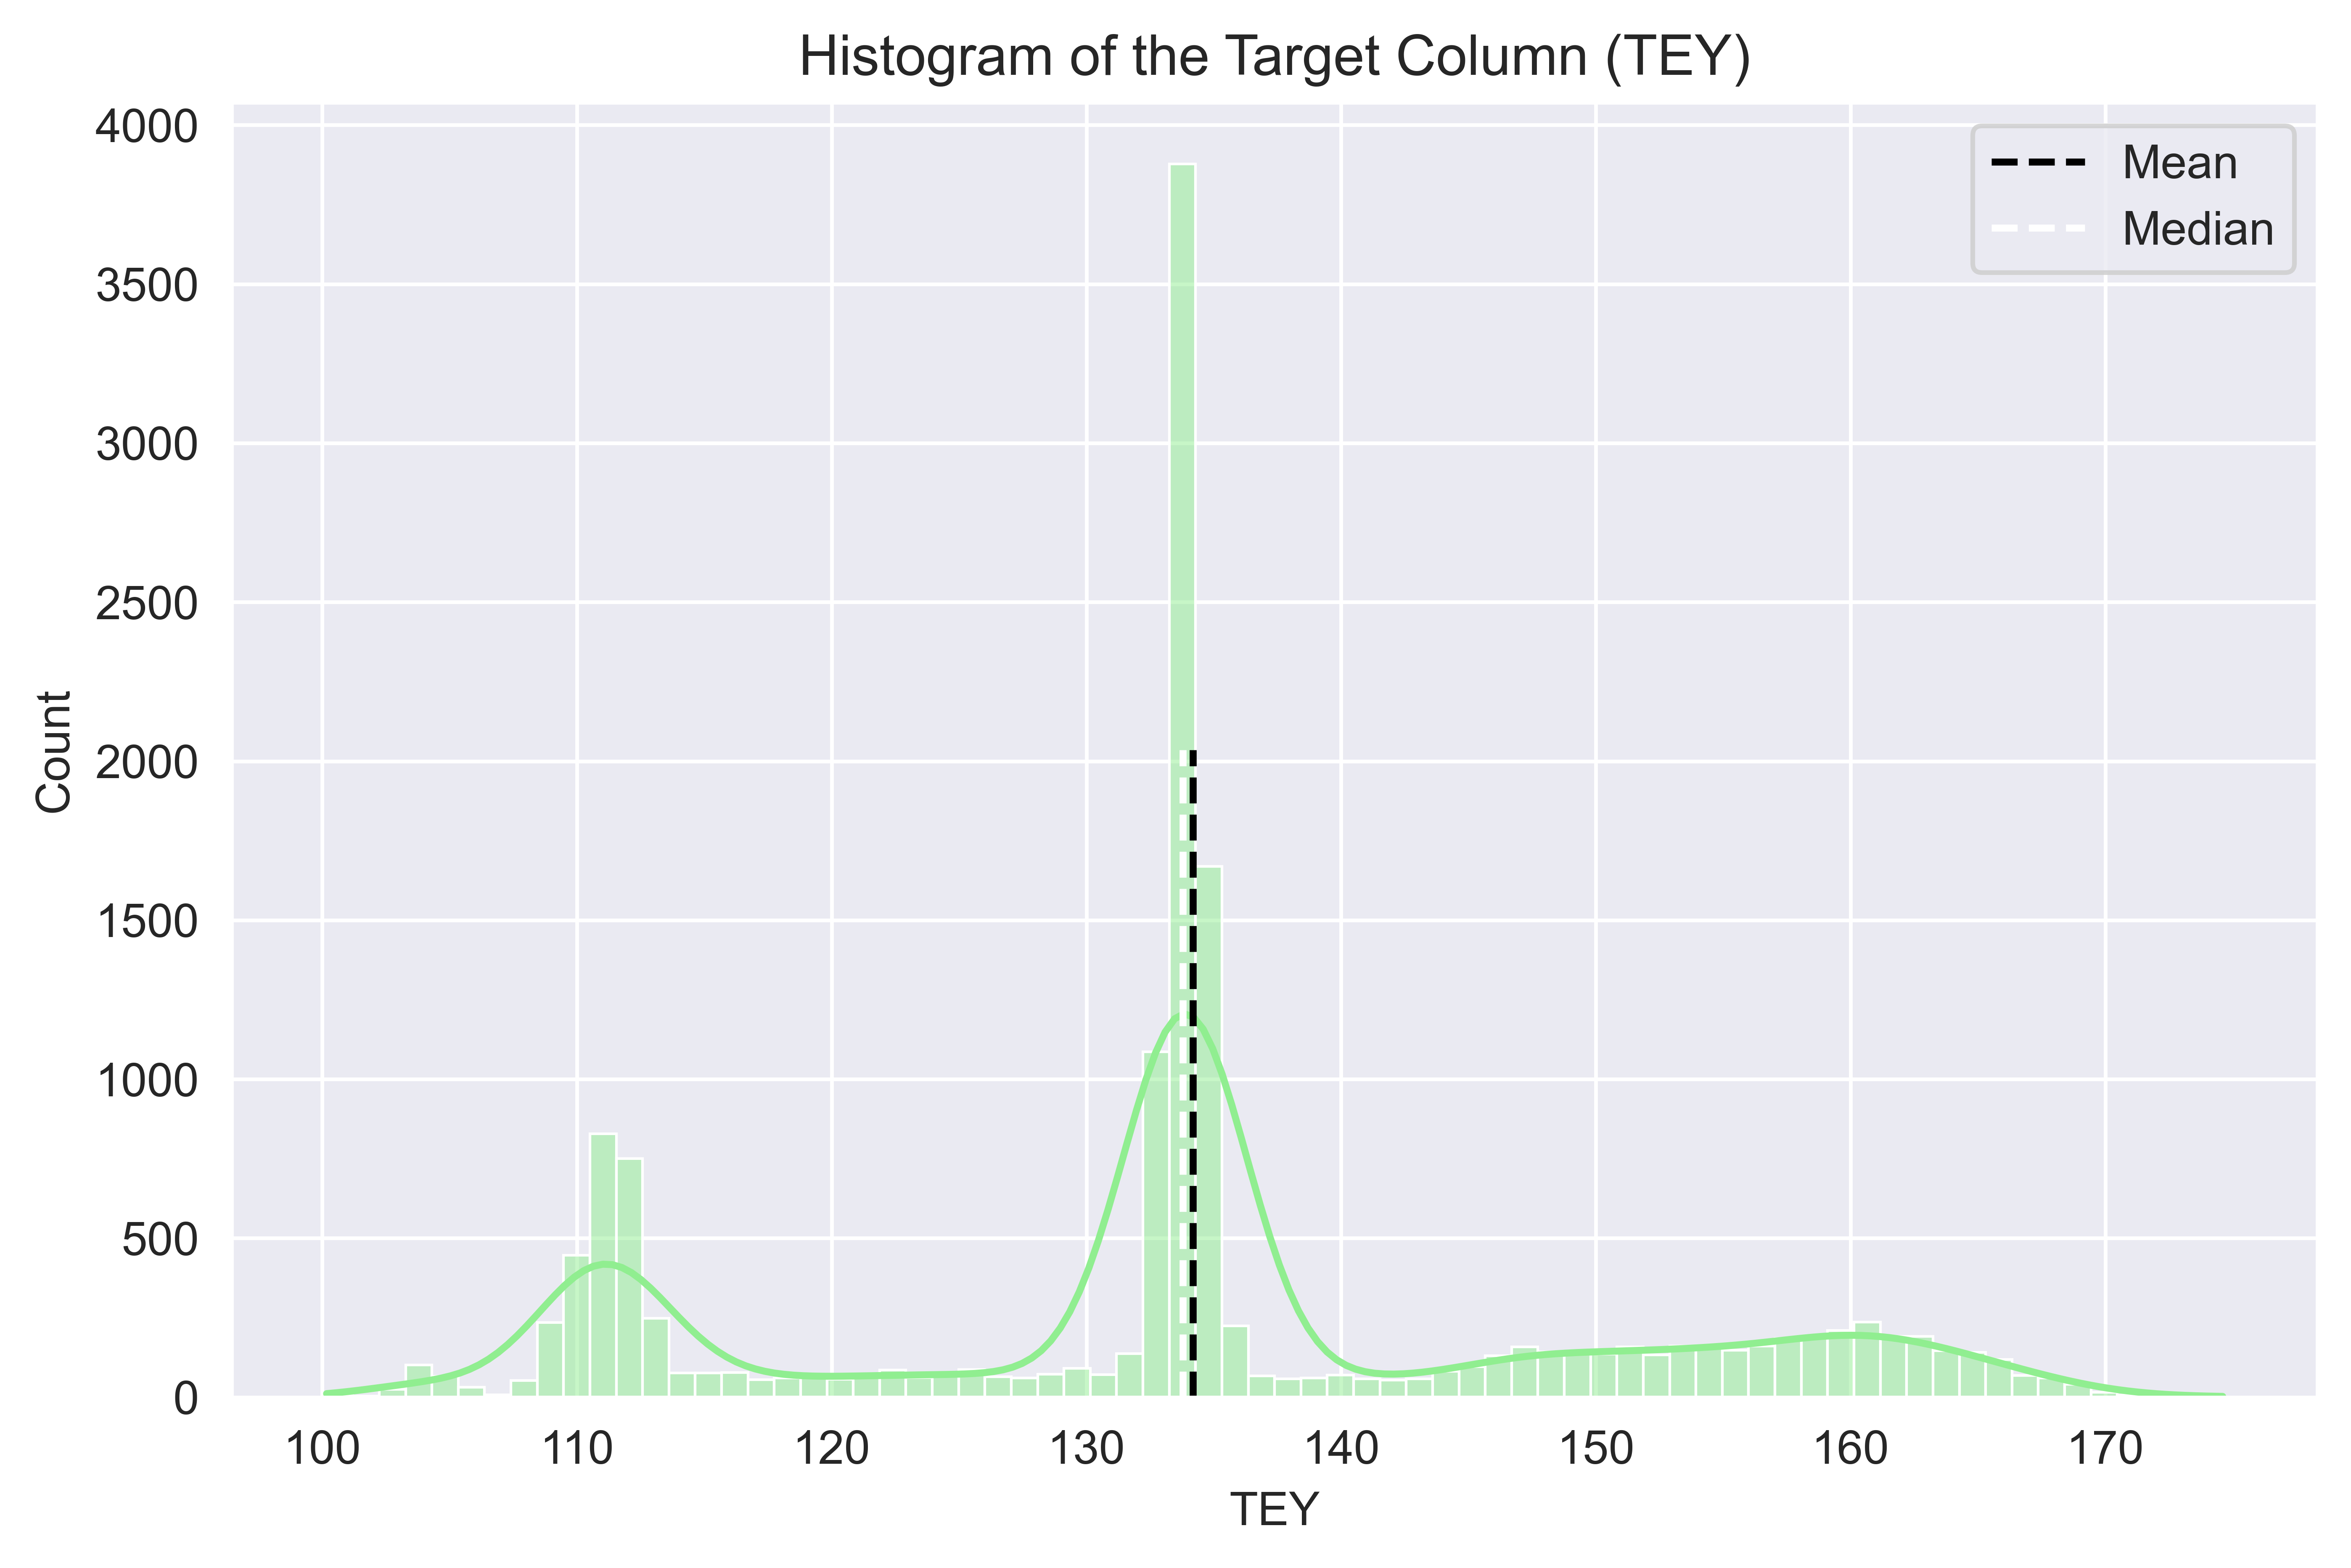

In [9]:
sns.set_style("darkgrid")
plt.figure(figsize=(8,5), dpi=800)
sns.histplot(data=df, x="TEY", color="lightgreen", kde=True)
plt.axvline(x=df["TEY"].mean(), ymax=0.5, color="black", linestyle='--', label="Mean")
plt.axvline(x=df["TEY"].median(), ymax=0.5, color="white", linestyle='--', label="Median")
plt.legend()
plt.title("Histogram of the Target Column (TEY)")

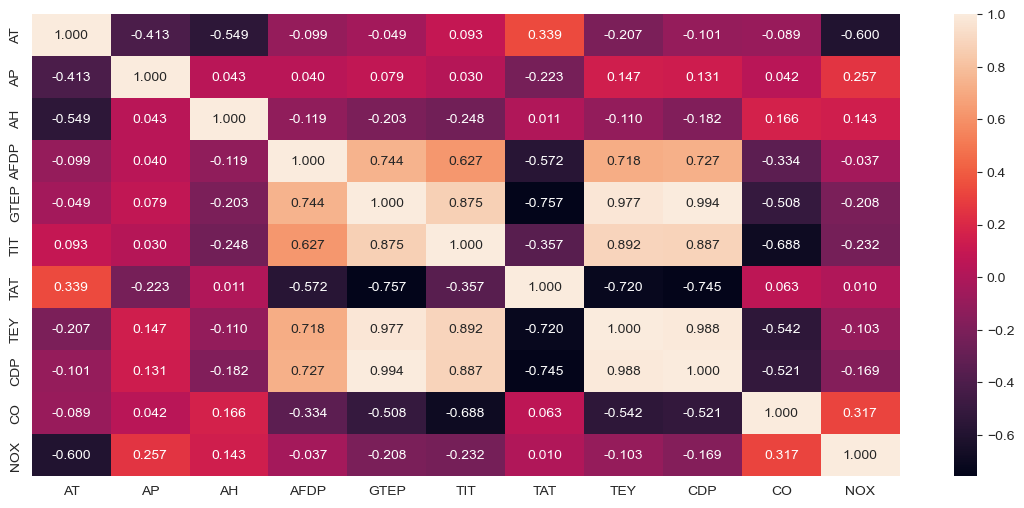

In [10]:
plt.figure(figsize=(14,6));
sns.heatmap(df.corr(), annot=True, fmt=".3f")
plt.show()

In [11]:
X=df1.iloc[:, :-1]
Y=df1.iloc[:,-1]
X_train, X_test, y_train, y_test=train_test_split(X,Y, test_size=0.3)

In [12]:
y_train=np.reshape(y_train.to_numpy(), (-1,1))
y_test=np.reshape(y_test.to_numpy(), (-1,1))

In [13]:
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

scaler_x.fit(X_train)
xtrain_scale=scaler_x.transform(X_train)

scaler_x.fit(X_test)
xtest_scale=scaler_x.transform(X_test)

scaler_y.fit(y_train)
ytrain_scale=scaler_y.transform(y_train)

scaler_y.fit(y_test)
ytest_scale=scaler_y.transform(y_test)

In [14]:
len(xtrain_scale)

10527

In [20]:
test = SelectKBest(score_func=mutual_info_regression, k='all')
fit = test.fit(X, Y)

In [22]:
scores=fit.scores_
features=fit.transform(X)

In [23]:
score_df = pd.DataFrame(list(zip(scores, X.columns)), columns =['Score', 'Feature'])
score_df.sort_values(by="Score", ascending=False, inplace=True)
score_df

,Score,Feature
0,0.412407,AT
1,0.138948,AP
2,0.097690,AH


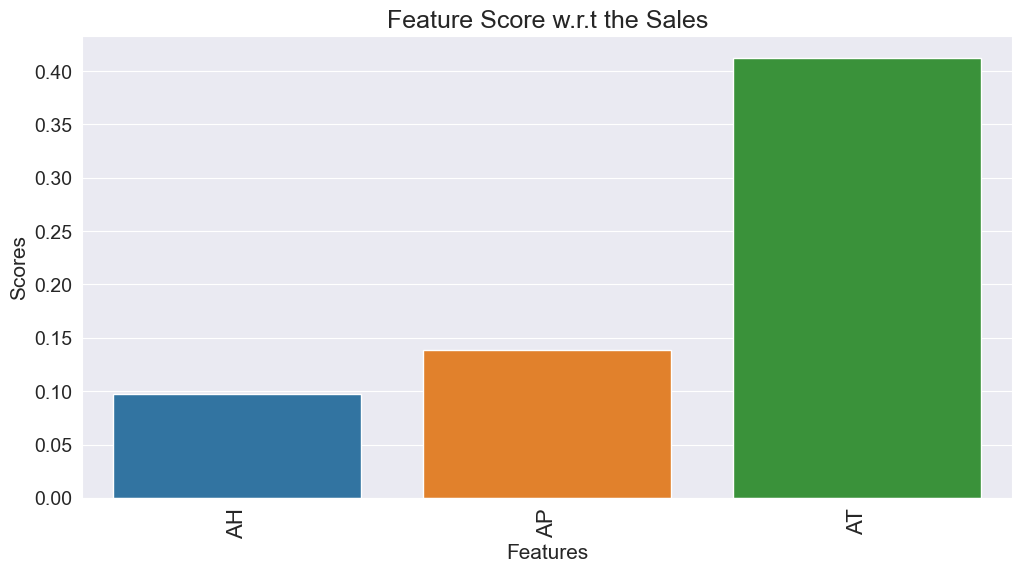

In [24]:
plt.figure(figsize=(12,6))
sns.barplot(x='Feature', y="Score", data=score_df, order=score_df.sort_values('Score').Feature)
plt.xlabel("Features", size=15)
plt.ylabel("Scores", size=15)
plt.yticks(rotation = 0, fontsize = 14)
plt.xticks(rotation = 90, fontsize = 16)
plt.title("Feature Score w.r.t the Sales", size=18)
plt.show()

In [25]:
model = Sequential()
model.add(Dense(4, input_dim=3, kernel_initializer='normal', activation='relu'))
model.add(Dense(2106,kernel_initializer='normal', activation='relu'))
model.add(Dense(1, activation='linear'))

model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mse','mae'])


hist = model.fit(xtrain_scale, ytrain_scale, validation_split=0.33, epochs=100, batch_size=150)

Epoch 1/100
48/48 [==============================] - 2s 18ms/step - loss: 0.0697 - mse: 0.0697 - mae: 0.2030 - val_loss: 0.0451 - val_mse: 0.0451 - val_mae: 0.1559
Epoch 2/100
48/48 [==============================] - 1s 13ms/step - loss: 0.0465 - mse: 0.0465 - mae: 0.1578 - val_loss: 0.0445 - val_mse: 0.0445 - val_mae: 0.1523
Epoch 3/100
48/48 [==============================] - 1s 12ms/step - loss: 0.0462 - mse: 0.0462 - mae: 0.1574 - val_loss: 0.0440 - val_mse: 0.0440 - val_mae: 0.1511
Epoch 4/100
48/48 [==============================] - 1s 18ms/step - loss: 0.0458 - mse: 0.0458 - mae: 0.1570 - val_loss: 0.0442 - val_mse: 0.0442 - val_mae: 0.1557
Epoch 5/100
48/48 [==============================] - 1s 11ms/step - loss: 0.0459 - mse: 0.0459 - mae: 0.1591 - val_loss: 0.0437 - val_mse: 0.0437 - val_mae: 0.1531
Epoch 6/100
48/48 [==============================] - 1s 11ms/step - loss: 0.0448 - mse: 0.0448 - mae: 0.1550 - val_loss: 0.0445 - val_mse: 0.0445 - val_mae: 0.1624
Epoch 7/100
48/4

Epoch 51/100
48/48 [==============================] - 1s 13ms/step - loss: 0.0393 - mse: 0.0393 - mae: 0.1587 - val_loss: 0.0383 - val_mse: 0.0383 - val_mae: 0.1572
Epoch 52/100
48/48 [==============================] - 1s 12ms/step - loss: 0.0391 - mse: 0.0391 - mae: 0.1587 - val_loss: 0.0380 - val_mse: 0.0380 - val_mae: 0.1549
Epoch 53/100
48/48 [==============================] - 1s 12ms/step - loss: 0.0390 - mse: 0.0390 - mae: 0.1583 - val_loss: 0.0380 - val_mse: 0.0380 - val_mae: 0.1526
Epoch 54/100
48/48 [==============================] - 1s 12ms/step - loss: 0.0390 - mse: 0.0390 - mae: 0.1575 - val_loss: 0.0385 - val_mse: 0.0385 - val_mae: 0.1549
Epoch 55/100
48/48 [==============================] - 1s 12ms/step - loss: 0.0391 - mse: 0.0391 - mae: 0.1577 - val_loss: 0.0384 - val_mse: 0.0384 - val_mae: 0.1557
Epoch 56/100
48/48 [==============================] - 1s 13ms/step - loss: 0.0391 - mse: 0.0391 - mae: 0.1580 - val_loss: 0.0393 - val_mse: 0.0393 - val_mae: 0.1582
Epoch 57/1

In [26]:
model1 = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='linear')])

model1.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae','mse'])

model1.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test))

Epoch 1/50
658/658 [==============================] - 4s 5ms/step - loss: 908.8173 - mae: 15.9547 - mse: 908.8173 - val_loss: 245.3956 - val_mae: 11.3484 - val_mse: 245.3956
Epoch 2/50
658/658 [==============================] - 3s 4ms/step - loss: 242.6026 - mae: 11.5736 - mse: 242.6026 - val_loss: 242.5890 - val_mae: 11.4009 - val_mse: 242.5890
Epoch 3/50
658/658 [==============================] - 3s 4ms/step - loss: 238.7267 - mae: 11.5735 - mse: 238.7267 - val_loss: 235.9313 - val_mae: 11.3527 - val_mse: 235.9313
Epoch 4/50
658/658 [==============================] - 3s 4ms/step - loss: 237.1140 - mae: 11.7318 - mse: 237.1140 - val_loss: 237.7983 - val_mae: 11.8062 - val_mse: 237.7983
Epoch 5/50
658/658 [==============================] - 3s 4ms/step - loss: 234.9298 - mae: 11.8389 - mse: 234.9298 - val_loss: 228.4561 - val_mae: 11.5601 - val_mse: 228.4561
Epoch 6/50
658/658 [==============================] - 3s 5ms/step - loss: 232.6254 - mae: 11.9225 - mse: 232.6254 - val_loss: 233.

Epoch 48/50
658/658 [==============================] - 3s 5ms/step - loss: 224.8877 - mae: 11.9688 - mse: 224.8877 - val_loss: 227.1742 - val_mae: 11.9595 - val_mse: 227.1742
Epoch 49/50
658/658 [==============================] - 3s 4ms/step - loss: 223.6371 - mae: 11.9158 - mse: 223.6371 - val_loss: 222.5545 - val_mae: 11.8637 - val_mse: 222.5545
Epoch 50/50
658/658 [==============================] - 3s 4ms/step - loss: 223.2581 - mae: 11.9406 - mse: 223.2581 - val_loss: 221.7182 - val_mae: 11.7534 - val_mse: 221.7182


In [27]:
model1.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 32)                128       
                                                                 
 dense_4 (Dense)             (None, 16)                528       
                                                                 
 dense_5 (Dense)             (None, 1)                 17        
                                                                 
Total params: 673 (2.63 KB)
Trainable params: 673 (2.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [28]:
y_predict = model.predict(xtest_scale)

141/141 [==============================] - 1s 3ms/step


In [29]:
y_pred1 = model1.predict(xtest_scale)

141/141 [==============================] - 0s 2ms/step


In [30]:
print(hist.history.keys())

dict_keys(['loss', 'mse', 'mae', 'val_loss', 'val_mse', 'val_mae'])


In [31]:
hist_df = pd.DataFrame(hist.history)
hist_df["epoch"]=hist.epoch
hist_df.tail()

,loss,mse,mae,val_loss,val_mse,val_mae,epoch
95,0.040605,0.040605,0.161453,0.038755,0.038755,0.155772,95
96,0.039186,0.039186,0.157108,0.038020,0.038020,0.154962,96
97,0.038855,0.038855,0.157607,0.039181,0.039181,0.156549,97
98,0.039809,0.039809,0.158135,0.037769,0.037769,0.152300,98
99,0.038683,0.038683,0.156102,0.038394,0.038394,0.154084,99
